# GSM8K — raw APIs (no eval-protocol)

A bare-metal version of the speed showdown: hits each provider through its **own native SDK**, no eval-protocol harness.

- **Anthropic** → the official `anthropic` SDK (`client.messages.create`).
- **Fireworks** → the `openai` SDK pointed at Fireworks' OpenAI-compatible endpoint (`client.chat.completions.create`).

Runs a small portion of GSM8K, grades with a regex, and clocks per-request latency. Useful to sanity-check what the harness is doing under the hood.

**Prereqs:** `FIREWORKS_API_KEY` and `ANTHROPIC_API_KEY` in `training/.env` or your shell.


In [1]:
# Run once if imports fail.
import sys
!{sys.executable} -m pip install -q anthropic openai matplotlib python-dotenv

In [2]:
# --- edit these ---
ANTHROPIC_MODEL = "claude-opus-4-8"                 # native Anthropic model id (no provider prefix)
FIREWORKS_5_1_MODEL = "accounts/fireworks/models/glm-5p1"  # native Fireworks model id
FIREWORKS_5_2_MODEL = "accounts/fireworks/models/glm-5p2"  # native Fireworks model id

MAX_ROWS = 50            # keep it small — this is a curiosity run
MAX_TOKENS = 10000
CONCURRENCY = 4
DATASET_URL = "https://raw.githubusercontent.com/eval-protocol/python-sdk/main/development/gsm8k_sample.jsonl"

In [3]:
import asyncio
import os
import re
import time
import urllib.request
from pathlib import Path

from dotenv import load_dotenv

training_dir = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "training" and (p / "pyproject.toml").exists()),
    Path("../../").resolve(),
)
load_dotenv(training_dir / ".env")

missing = [k for k in ("FIREWORKS_API_KEY", "ANTHROPIC_API_KEY") if not os.getenv(k)]
if missing:
    raise EnvironmentError(f"Missing {missing}. Set them in {training_dir / '.env'} or your shell.")

In [4]:
def load_rows(url: str, max_rows: int) -> list[dict]:
    raw = urllib.request.urlopen(url).read().decode().splitlines()
    rows = [json.loads(line) for line in raw if line.strip()][:max_rows]
    return rows


import json
rows = load_rows(DATASET_URL, MAX_ROWS)
print(f"Loaded {len(rows)} GSM8K rows")

# Each row: {"messages": [system, user], "ground_truth": "...<answer>N</answer>"}
def split_messages(row: dict):
    system = next((m["content"] for m in row["messages"] if m["role"] == "system"), None)
    user = next((m["content"] for m in row["messages"] if m["role"] == "user"), "")
    return system, user

Loaded 50 GSM8K rows


In [5]:
_ANSWER_TAG_RE = re.compile(r"<answer>\s*(.*?)\s*</answer>", re.IGNORECASE | re.DOTALL)
_DIGITS_RE = re.compile(r"(-?\d+(?:\.\d+)?)")


def extract_answer(text: str) -> str | None:
    if not text:
        return None
    m = _ANSWER_TAG_RE.search(text)
    chunk = m.group(1) if m else text
    digits = _DIGITS_RE.findall(chunk.replace(",", ""))
    return digits[-1] if digits else None

## Per-provider call functions

Each returns `(text, latency_seconds)`. Note the SDK differences:

- **Anthropic**: `system` is a top-level param (not a message); we do **not** pass `temperature` (Opus 4.8 rejects it).
- **Fireworks (OpenAI-compatible)**: `system` goes in the `messages` array; `temperature` is accepted.

In [6]:
from anthropic import AsyncAnthropic
from openai import AsyncOpenAI

anthropic_client = AsyncAnthropic()  # reads ANTHROPIC_API_KEY
fireworks_client = AsyncOpenAI(
    base_url="https://api.fireworks.ai/inference/v1",
    api_key=os.environ["FIREWORKS_API_KEY"],
)


async def call_anthropic(system: str, user: str) -> tuple[str, float]:
    t0 = time.perf_counter()
    resp = await anthropic_client.messages.create(
        model=ANTHROPIC_MODEL,
        max_tokens=MAX_TOKENS,
        system=system,
        messages=[{"role": "user", "content": user}],
    )
    dt = time.perf_counter() - t0
    text = "".join(b.text for b in resp.content if b.type == "text")
    return text, dt


async def call_fireworks(model: str, system: str, user: str) -> tuple[str, float]:
    msgs = []
    if system:
        msgs.append({"role": "system", "content": system})
    msgs.append({"role": "user", "content": user})
    t0 = time.perf_counter()
    resp = await fireworks_client.chat.completions.create(
        model=model,
        max_tokens=MAX_TOKENS,
        temperature=0.0,
        messages=msgs,
    )
    dt = time.perf_counter() - t0
    return resp.choices[0].message.content or "", dt


PROVIDERS = {
    "GLM-5.2 (Fireworks)": lambda s, u: call_fireworks(FIREWORKS_5_2_MODEL, s, u),
    "GLM-5.1 (Fireworks)": lambda s, u: call_fireworks(FIREWORKS_5_1_MODEL, s, u),
    "Opus 4.8 (Anthropic)": call_anthropic,
}

In [7]:
async def benchmark(name: str, call_fn, rows: list[dict]) -> dict:
    sem = asyncio.Semaphore(CONCURRENCY)

    async def one(row):
        system, user = split_messages(row)
        gt = extract_answer(str(row["ground_truth"]))
        async with sem:
            try:
                text, dt = await call_fn(system, user)
            except Exception as e:  # noqa: BLE001
                return {"ok": False, "error": repr(e)[:200]}
        pred = extract_answer(text)
        return {"ok": True, "latency": dt, "score": 1.0 if (pred and pred == gt) else 0.0,
                "pred": pred, "gt": gt}

    wall0 = time.perf_counter()
    out = await asyncio.gather(*(one(r) for r in rows))
    wall = time.perf_counter() - wall0

    ok = [r for r in out if r["ok"]]
    errs = [r for r in out if not r["ok"]]
    if errs:
        print(f"  {name}: {len(errs)} errors, e.g. {errs[0]['error']}")
    lat = sorted(r["latency"] for r in ok)
    acc = (sum(r["score"] for r in ok) / len(ok)) if ok else 0.0
    print(f"{name}: {len(ok)}/{len(rows)} ok | acc {acc:.0%} | "
          f"mean {sum(lat)/len(lat):.1f}s | wall {wall:.1f}s")
    return {"name": name, "latencies": lat, "accuracy": acc, "wall": wall, "n": len(ok)}


results = {}
for name, fn in PROVIDERS.items():
    results[name] = await benchmark(name, fn, rows)

GLM-5.2 (Fireworks): 50/50 ok | acc 90% | mean 9.1s | wall 117.8s
GLM-5.1 (Fireworks): 50/50 ok | acc 96% | mean 10.0s | wall 127.0s
Opus 4.8 (Anthropic): 50/50 ok | acc 92% | mean 3.6s | wall 56.4s


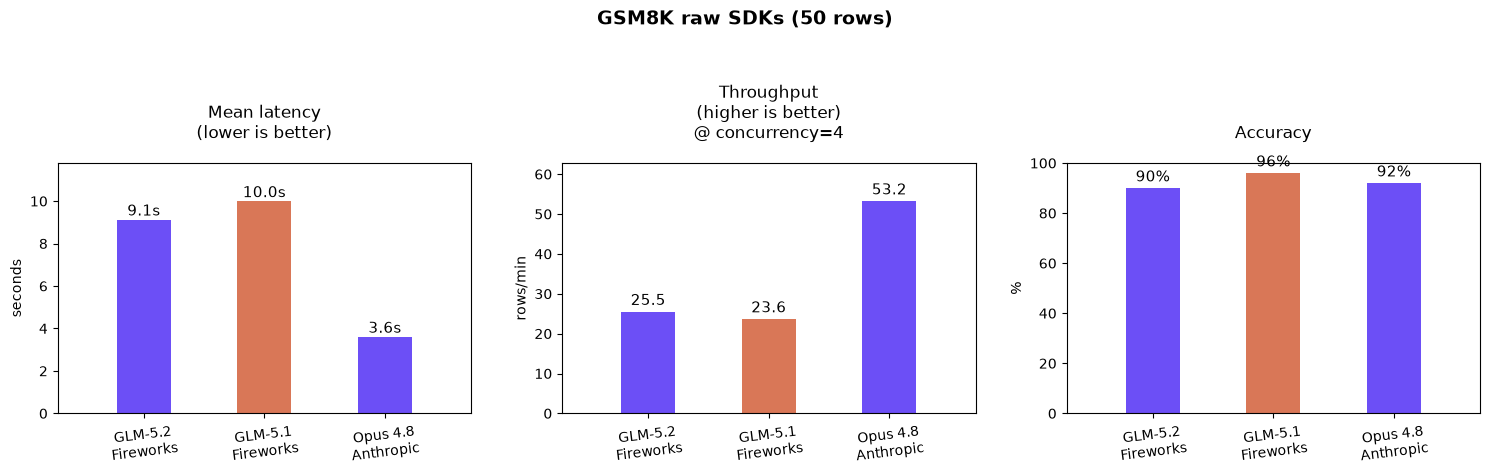

Saved gsm8k_raw_api.png


In [8]:
import matplotlib.pyplot as plt

names = list(results.keys())
colors = ["#6C4FF6", "#D97757"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle(f"GSM8K raw SDKs ({MAX_ROWS} rows)", fontsize=14, fontweight="bold")

bar_width = 0.45
spacing = [n.replace(" (Fireworks)", "\nFireworks").replace(" (Anthropic)", "\nAnthropic") for n in names]

# 1. Mean latency
ax = axes[0]
vals = [(sum(results[n]["latencies"]) / len(results[n]["latencies"])) if results[n]["latencies"] else 0 for n in names]
bars = ax.bar(spacing, vals, color=colors, width=bar_width)
ax.set_title("Mean latency\n(lower is better)", pad=18)
ax.set_ylabel("seconds")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.1f}s", ha="center", va="bottom", fontsize=11)
ax.set_ylim([0, max(vals)*1.18 if vals else 1])

# 2. Throughput
ax = axes[1]
vals = [(results[n]["n"] / results[n]["wall"] * 60) if results[n]["wall"] else 0 for n in names]
bars = ax.bar(spacing, vals, color=colors, width=bar_width)
# Explicitly mention higher is better in the title
ax.set_title(f"Throughput\n(higher is better)\n@ concurrency={CONCURRENCY}", pad=18)
ax.set_ylabel("rows/min")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}", ha="center", va="bottom", fontsize=11)
ax.set_ylim([0, max(vals)*1.18 if vals else 1])

# 3. Accuracy
ax = axes[2]
vals = [results[n]["accuracy"] * 100 for n in names]
bars = ax.bar(spacing, vals, color=colors, width=bar_width)
ax.set_title("Accuracy", pad=18)
ax.set_ylabel("%")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.0f}%", ha="center", va="bottom", fontsize=11)
ax.set_ylim(0, 100)

for ax in axes:
    ax.tick_params(axis="x", labelrotation=7)
    ax.margins(x=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.subplots_adjust(wspace=0.22)
plt.savefig("gsm8k_raw_api.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved gsm8k_raw_api.png")

### Notes

- This is the same task as `gsm8k_speed_showdown.ipynb` but with **no eval-protocol layer** — just the two vendor SDKs. Handy for confirming behavior or debugging without the harness in the way.
- Anthropic's `system` prompt is a top-level argument; Fireworks (OpenAI shape) takes it as the first message. Opus 4.8 rejects `temperature`, so it's omitted on that path only.
- GLM-5.2 is MoE / nondeterministic at temp 0 — accuracy on 20 rows is directional, not a verdict.